Задача №1

Система состоит из устройств типа A и типа B, интенсивности отказов λA и λB известны. Для функционирования системы требуется хотя бы одно устройство типа A и хотя бы NB устройств типа B. Также имеются резервные устройства в количествах RA и RB соответственно, причём в нормальном состоянии одновременно включены сразу NA устройств типа A.


Если N – номер зачётной книжки, а G – последняя цифра в номере группы, то параметры системы определяются следующим образом:

λA= G + (N mod 3)

λB= G + (N mod 5)

NA= 2 + (G mod 2)

NB= 1 + (N mod 2)

RA= 1 + (G mod 2)

RB= 2 – (G mod 2)


Требуется:

1.	нарисовать граф состояний системы;
2.	составить матрицу интенсивностей переходов;
3.	записать дифференциальные уравнения Колмогорова;
4.	методами численного интегрирования решить полученную систему дифференциальных уравнений, исходя из того, что в начальный момент времени все устройства исправны;
5.	построить графики вероятностей нахождения системы в каждом из возможных состояний с течением времени;
6.	построить график функции надёжности системы;
7.	рассчитать математическое ожидание времени безотказной работы;
8.	провести имитационное моделирование системы в терминах непрерывных марковских цепей 100 раз, рассчитать среднее выборочное значение и стандартное отклонение времени безотказной работы системы.

Задача №2

Рассматривается система, аналогичная задаче №1, но в которой возможна организация ремонта ранее вышедших из строя устройств. Одновременно может ремонтироваться только одно устройство. Если подлежат ремонту устройства разных типов, приоритет отдаётся тем, которых сломалось больше, а если их сломалось одинаковое число – тому типу, интенсивность поломок которого выше. Интенсивность ремонта устройств обоих типов одинакова и равна λS= (NA + NB – (G mod 2)) * (G + (N mod 4)).

Требуется:

1.	нарисовать граф состояний системы;
2.	составить матрицу интенсивностей переходов;
3.	записать алгебраические уравнения Колмогорова для установившегося режима работы;
4.	рассчитать предельные вероятности состояний системы;
5.	рассчитать математические ожидания прикладных характеристик системы:

  ●	вероятности отказа системы;

  ●	числа готовых к эксплуатации устройств каждого типа;

  ●	коэффициента загрузки ремонтной службы.

6.	записать дифференциальные уравнения Колмогорова;
7.	методами численного интегрирования решить полученную систему
дифференциальных уравнений, исходя из того, что в начальный момент времени все устройства исправны, а время моделирования выбирается вдвое больше теоретической оценки времени переходного процесса (т.е. того времени, которое необходимо, чтобы эвклидова норма вектора невязки с ранее рассчитанным предельным вектором составляла не более 1% эвклидовой нормы последнего);
8.	построить графики вероятностей нахождения системы в каждом из возможных состояний с течением времени;
9.	провести имитационное моделирование системы в терминах непрерывных марковских цепей 1 раз, время моделирования определяется расчётом в п.7;
10.	провести имитационное моделирование системы в терминах дискретно-событийного моделирования (с независимым планированием времени наступления событий для каждого устройства в отдельности) 1 раз, время моделирования определяется расчётом в п.7.


In [ ]:
G = 21
N = 3

lambda_A = G + (N % 3) # λA

lambda_B = G + (N % 5) # λB

N_A = 2 + (G % 2) # NA

N_B = 1 + (N % 2) # NB

R_A = 1 + (G % 2) # RA

R_B = 2 - (G % 2) # RB

lambda_S = (N_A + N_B - (G % 2)) * (G + (N % 4))

print(f'Интенсивности отказов λ: A-{lambda_A}, B-{lambda_B}\n', f'Количество устройсчтв N: A-{N_A}, B-{N_B}\n', f'Резервных устройств R: A-{R_A}, B-{R_B}\n')

Интенсивности отказов λ: A-21, B-24
 Количество устройсчтв N: A-3, B-2
 Резервных устройств R: A-2, B-1



In [1]:
# Для задачи №1

# import numpy as np
# from collections import deque

# class State:
#     def __init__(self, wa, ra, wb, rb, name):
#         self.wa = wa          # работающие A
#         self.ra = ra          # резервные A
#         self.wb = wb          # работающие B
#         self.rb = rb          # резервные B
#         self.name = name      # S_n
#         self.transitions = [] # список (state, intensity)

#     def add_transition(self, state, intensity):
#         self.transitions.append((state, intensity))

#     def is_operational(self, NB):
#         return self.wa >= 1 and self.wb >= NB

#     def __repr__(self):
#         return f"{self.name}(A: {self.wa}+{self.ra}, B: {self.wb}+{self.rb})"


# class Graph:
#     def __init__(self, NA, NB, RA, RB, lambdaA, lambdaB):
#         self.NA = NA
#         self.NB = NB
#         self.RA = RA
#         self.RB = RB
#         self.lambdaA = lambdaA
#         self.lambdaB = lambdaB
#         self.states = {}          # key: (wa, ra, wb, rb) -> State
#         self.counter = 0          # для нумерации S_n

#     def _get_next_name(self):
#         self.counter += 1
#         return f"S_{self.counter}"

#     def _add_state(self, wa, ra, wb, rb):
#         key = (wa, ra, wb, rb)
#         if key not in self.states:
#             name = self._get_next_name()
#             self.states[key] = State(wa, ra, wb, rb, name)
#         return self.states[key]

#     def build(self):
#         start_state = self._add_state(self.NA, self.RA, self.NB, self.RB)
#         queue = deque([start_state])
#         processed = set()

#         while queue:
#             s = queue.popleft()
#             if s in processed:
#                 continue
#             processed.add(s)

#             # Если состояние уже неработоспособно, не строим переходы из него
#             if not s.is_operational(self.NB):
#                 continue

#             # Отказ работающего A
#             if s.wa > 0:
#                 if s.ra > 0:
#                     # есть резерв → работающие не меняются, резерв уменьшается
#                     next_state = self._add_state(s.wa, s.ra - 1, s.wb, s.rb)
#                 else:
#                     # нет резерва → работающие уменьшаются
#                     next_state = self._add_state(s.wa - 1, 0, s.wb, s.rb)
#                 intensity = s.wa * self.lambdaA
#                 s.add_transition(next_state, intensity)
#                 queue.append(next_state)

#             # Отказ работающего B
#             if s.wb > 0:
#                 if s.rb > 0:
#                     next_state = self._add_state(s.wa, s.ra, s.wb, s.rb - 1)
#                 else:
#                     next_state = self._add_state(s.wa, s.ra, s.wb - 1, 0)
#                 intensity = s.wb * self.lambdaB
#                 s.add_transition(next_state, intensity)
#                 queue.append(next_state)

#     def adjacency_matrix(self):
#         states_list = sorted(self.states.values(), key=lambda st: int(st.name[2:]))
#         index = {st: i for i, st in enumerate(states_list)}
#         n = len(states_list)
#         matrix = np.zeros((n, n))
#         for st in states_list:
#             i = index[st]
#             for nxt, intens in st.transitions:
#                 j = index[nxt]
#                 matrix[i][j] = intens
#         return matrix, states_list

#     def get_operational_states(self):
#         return [st for st in self.states.values() if st.is_operational(self.NB)]

#     def get_failure_states(self):
#         return [st for st in self.states.values() if not st.is_operational(self.NB)]

#     def print_states(self):
#         print("Все состояния:")
#         for st in self.states.values():
#             status = " (исправно)" if st.is_operational(self.NB) else " (неисправно)"
#             print(f"{st.name}: wa={st.wa}, ra={st.ra}, wb={st.wb}, rb={st.rb}{status}")

#     def generator_matrix(self):
#       adj, states = self.adjacency_matrix()
#       n = adj.shape[0]
#       gen = np.zeros((n, n))

#       for i in range(n):
#           for j in range(n):
#               if i != j:
#                   gen[i][j] = adj[i][j]

#       for i in range(n):
#           gen[i][i] = -np.sum(gen[i])

#       return gen

# # N_A = 2
# # N_B = 2
# # R_A = 1
# # R_B = 2
# # lambda_A = 4
# # lambda_B = 3

# g = Graph(N_A, N_B, R_A, R_B, lambda_A, lambda_B)
# g.build()

# # g.print_states()
# print(f"\nВсего состояний: {len(g.states)}")
# # print(f"Работоспособных: {len(g.get_operational_states())}")
# # print(f"Неисправных: {len(g.get_failure_states())}")

# matrix, states_list = g.adjacency_matrix()
# print("\nМатрица смежности:\n", matrix)

# # print("\nПорядок состояний в матрице:")
# # for i, st in enumerate(states_list):
# #     print(f"{i}: {st.name}")

# np.set_printoptions(linewidth=200)

# Q = g.generator_matrix()
# print(Q)

In [ ]:
import numpy as np
from collections import deque

np.set_printoptions(linewidth=200, precision=2, suppress=True)

class State:
    def __init__(self, wa, ra, wb, rb, name):
        self.wa = wa
        self.ra = ra
        self.wb = wb
        self.rb = rb
        self.name = name      # S_n
        self.transitions = []

    def add_transition(self, state, intensity):
        self.transitions.append((state, intensity))

    def is_operational(self, NB):
        return self.wa >= 1 and self.wb >= NB

    def __repr__(self):
        return f"{self.name}(A: {self.wa}+{self.ra}, B: {self.wb}+{self.rb})"


class GraphWithRepair:
    def __init__(self, NA, NB, RA, RB, lambdaA, lambdaB, lambdaS):
        self.NA = NA
        self.NB = NB
        self.RA = RA
        self.RB = RB
        self.lambdaA = lambdaA
        self.lambdaB = lambdaB
        self.lambdaS = lambdaS          # интенсивность ремонта
        self.states = {}
        self.counter = 0

    def _get_next_name(self):
        self.counter += 1
        return f"S_{self.counter}"

    def _add_state(self, wa, ra, wb, rb):
        key = (wa, ra, wb, rb)
        if key not in self.states:
            name = self._get_next_name()
            self.states[key] = State(wa, ra, wb, rb, name)
        return self.states[key]

    def _broken_count(self, wa, ra, total):
        return total - (wa + ra)

    def _repair_priority(self, brokenA, brokenB):
        """Возвращает тип ('A', 'B' или None) для ремонта по приоритету"""
        if brokenA == 0 and brokenB == 0:
            return None
        if brokenA > brokenB:
            return 'A'
        if brokenB > brokenA:
            return 'B'
        # равное количество – приоритет у типа с большей интенсивностью отказов
        if self.lambdaA >= self.lambdaB:
            return 'A'
        else:
            return 'B'

    def build(self):
        totalA = self.NA + self.RA
        totalB = self.NB + self.RB
        start_state = self._add_state(self.NA, self.RA, self.NB, self.RB)
        queue = deque([start_state])
        processed = set()

        while queue:
            s = queue.popleft()
            if s in processed:
                continue
            processed.add(s)

            # ---- Отказы ----
            # Отказ работающего A
            if s.wa > 0:
                if s.ra > 0:
                    next_state = self._add_state(s.wa, s.ra - 1, s.wb, s.rb)
                else:
                    next_state = self._add_state(s.wa - 1, 0, s.wb, s.rb)
                intensity = s.wa * self.lambdaA
                s.add_transition(next_state, intensity)
                queue.append(next_state)

            # Отказ работающего B
            if s.wb > 0:
                if s.rb > 0:
                    next_state = self._add_state(s.wa, s.ra, s.wb, s.rb - 1)
                else:
                    next_state = self._add_state(s.wa, s.ra, s.wb - 1, 0)
                intensity = s.wb * self.lambdaB
                s.add_transition(next_state, intensity)
                queue.append(next_state)

            # ---- Ремонт (только одно устройство за раз) ----
            brokenA = self._broken_count(s.wa, s.ra, totalA)
            brokenB = self._broken_count(s.wb, s.rb, totalB)
            priority = self._repair_priority(brokenA, brokenB)

            if priority == 'A' and brokenA > 0:
                # Восстановление A
                if s.wa < self.NA:
                    # увеличиваем работающие
                    next_state = self._add_state(s.wa + 1, s.ra, s.wb, s.rb)
                else:
                    # увеличиваем резерв
                    next_state = self._add_state(s.wa, s.ra + 1, s.wb, s.rb)
                s.add_transition(next_state, self.lambdaS)
                queue.append(next_state)

            elif priority == 'B' and brokenB > 0:
                # Восстановление B
                if s.wb < self.NB:
                    next_state = self._add_state(s.wa, s.ra, s.wb + 1, s.rb)
                else:
                    next_state = self._add_state(s.wa, s.ra, s.wb, s.rb + 1)
                s.add_transition(next_state, self.lambdaS)
                queue.append(next_state)

    def get_operational_states(self):
        return [st for st in self.states.values() if st.is_operational(self.NB)]

    def adjacency_matrix(self):
        states_list = sorted(self.states.values(), key=lambda st: int(st.name[2:]))
        index = {st: i for i, st in enumerate(states_list)}
        n = len(states_list)
        matrix = np.zeros((n, n))
        for st in states_list:
            i = index[st]
            for nxt, intens in st.transitions:
                j = index[nxt]
                matrix[i][j] = intens
        return matrix, states_list

    def generator_matrix(self):
        adj, states = self.adjacency_matrix()
        n = adj.shape[0]
        gen = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i != j:
                    gen[i][j] = adj[i][j]
        for i in range(n):
            gen[i][i] = -np.sum(gen[i])
        return gen

    def print_states(self):
        print("Все состояния:")
        for st in self.states.values():
            status = " (исправно)" if st.is_operational(self.NB) else " (неисправно)"
            print(f"{st.name}: wa={st.wa}, ra={st.ra}, wb={st.wb}, rb={st.rb}{status}")



g = GraphWithRepair(N_A, N_B, R_A, R_B, lambda_A, lambda_B, lambda_S)
g.build()

print(f"Всего состояний: {len(g.states)}")
# g.print_states()

matrix, states_list = g.adjacency_matrix()
print("\nМатрица смежности:\n", matrix)

Q = g.generator_matrix()
print("\nМатрица интенсивностей:\n", Q)

Всего состояний: 24

Матрица смежности:
 [[ 0. 63. 48.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [96.  0.  0. 63. 48.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [96.  0.  0.  0. 63. 48.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 96.  0.  0.  0.  0. 63. 48.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. 96.  0.  0.  0.  0.  0. 63. 48.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. 96.  0.  0.  0.  0.  0. 63. 24.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 96.  0.  0.  0.  0.  0.  0. 42. 48.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 96.  0.  0.  0.  0.  0.  0. 63. 48.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. 96.  0.  0.  0.  0.  0.  0.  0. 63. 24.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. 96.  0.  0.  0.  0.  0.  0.  0. 63.  0.  0.  0

Граф задания 1

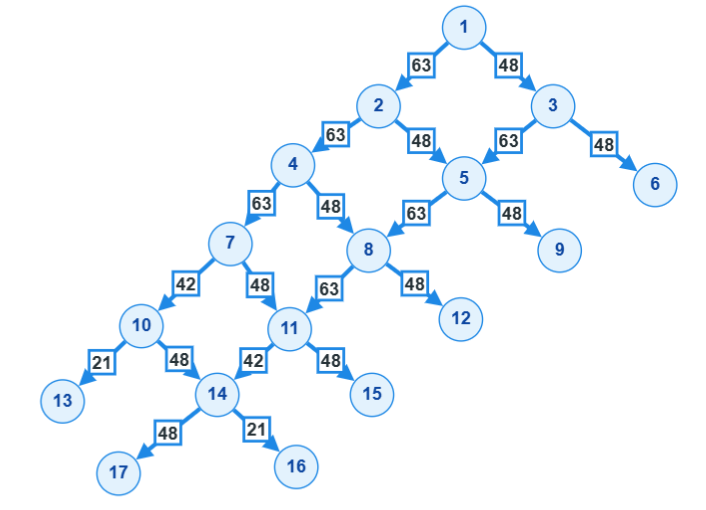

Граф задания 2

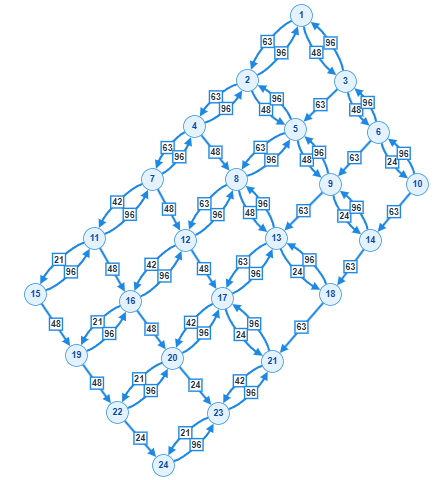

[[1.   0.98 0.96 ... 0.11 0.11 0.11]
 [0.   0.01 0.02 ... 0.09 0.09 0.09]
 [0.   0.01 0.02 ... 0.03 0.03 0.03]
 ...
 [0.   0.   0.   ... 0.01 0.01 0.01]
 [0.   0.   0.   ... 0.04 0.04 0.04]
 [0.   0.   0.   ... 0.01 0.01 0.01]]
-8.408568745906325e-10


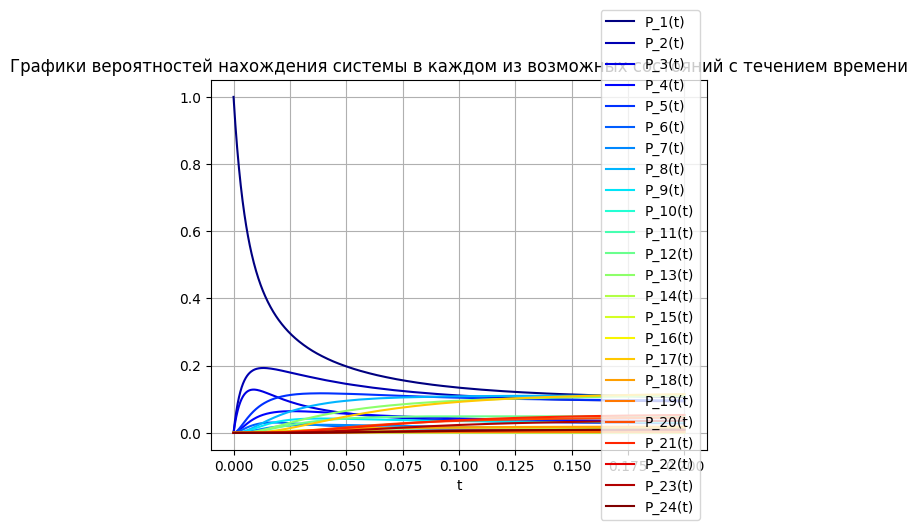

In [ ]:
from scipy.integrate import solve_ivp

# Q[-1] = 1.
# P = np.zeros((Q.shape[0], 1))
# P[-1] = 1


def dP_dt(t, P): return Q.T @ P


P0 = np.zeros(Q.shape[0])
P0[0] = 1.0

sol = solve_ivp(dP_dt, [0, 0.2], P0, t_eval=np.linspace(0, 0.2, 1000))
t = sol.t
P = sol.y
print(P.round(5))
print(P.min())


import matplotlib.pyplot as plt

colors = plt.cm.jet(np.linspace(0, 1, Q.shape[0]))  # viridis, plasma, jet, inferno, rainbow

for i in range (Q.shape[0]):
  plt.plot(t, P[i], color=colors[i], label='P_' + str(i + 1) +'(t)')
plt.legend(loc='right')
plt.title('Графики вероятностей нахождения системы в каждом из возможных состояний с течением времени')
plt.xlabel('t')
plt.grid()
plt.show()

In [ ]:
import numpy as np
from scipy.linalg import lstsq

# стационарное распределение π из системы π Q = 0, ∑π = 1
n = Q.shape[0]
A = np.vstack([Q.T, np.ones(n)]) # + условие нормировки
b = np.zeros(n + 1)
b[-1] = 1.0
pi, _, _, _ = lstsq(A, b) # метод наименьших квадратов
pi = pi / pi.sum() # гарантия нормировки

# Индексы неработоспособных состояний
failure_indices = [i for i, st in enumerate(states_list) if not st.is_operational(g.NB)]

# Вероятность отказа системы
P_failure = pi[failure_indices].sum()

# Среднее число исправных устройств (работающие + резервные)
E_ready_A = sum(pi[i] * (st.wa + st.ra) for i, st in enumerate(states_list))
E_ready_B = sum(pi[i] * (st.wb + st.rb) for i, st in enumerate(states_list))


initial_state_key = (g.NA, g.RA, g.NB, g.RB) # Коэффициент загрузки ремонтника
initial_state = g.states[initial_state_key] # Ремонтник занят, если есть хотя бы одно сломанное устройство
initial_idx = states_list.index(initial_state) # Состояние, где все устройства исправны, единственно: (NA, RA, NB, RB)
utilization = 1 - pi[initial_idx]

print(f"Вероятность отказа системы: {P_failure:.6f}")
print(f"Среднее число готовых A: {E_ready_A:.4f}")
print(f"Среднее число готовых B: {E_ready_B:.4f}")
print(f"Коэффициент загрузки ремонтника: {utilization:.4f}")


# op_st = g.get_operational_states()

# operational_states = []
# for i in range(len(op_st)):
#   operational_states.append(int(op_st[i].name[2:]) - 1)

# R_t = np.sum(P.T[:, operational_states], axis=1)
# plt.xlabel('t')
# plt.plot(t, R_t)
# plt.title('График функции надёжности системы')
# plt.show()

Вероятность отказа системы: 0.457985
Среднее число готовых A: 2.9857
Среднее число готовых B: 1.6595
Коэффициент загрузки ремонтника: 0.8977


Время переходного процесса: 0.4000
Время моделирования: 0.8000


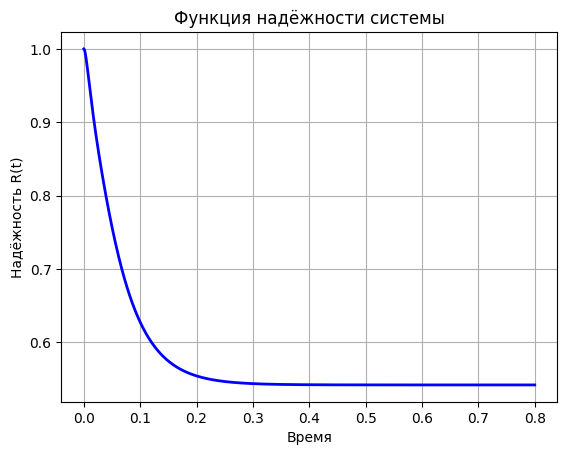

In [ ]:
from scipy.integrate import solve_ivp

# Начальное условие
P0 = np.zeros(n)
P0[0] = 1.0

def dP_dt(t, P):
    return Q.T @ P

# Находим стационарное распределение (используем pi из предыдущего пункта)
pi_norm = np.linalg.norm(pi)

# Поиск времени переходного процесса
t_max = 0.1          # начальное предположение
dt = 0.01
t_span = (0, t_max)
t_eval = np.arange(0, t_max + dt, dt)
sol = solve_ivp(dP_dt, t_span, P0, t_eval=t_eval, method='DOP853', atol=1e-10, rtol=1e-8)
P = sol.y

found = False
while not found:
    # Находим максимальную эвклидову норму невязки на последнем отрезке
    # (используем последние 10% точек для устойчивости)
    n_last = max(1, int(len(t_eval) * 0.1))
    errors = []
    for i in range(-n_last, 0):
        err = np.linalg.norm(P[:, i] - pi) / pi_norm
        errors.append(err)
    max_err = max(errors)
    if max_err < 0.01:
        found = True
        T_trans = t_eval[-1]          # последнее время
    else:
        # Увеличиваем интервал
        t_max *= 2
        t_span = (0, t_max)
        t_eval = np.arange(0, t_max + dt, dt)
        sol = solve_ivp(dP_dt, t_span, P0, t_eval=t_eval, method='DOP853', atol=1e-10, rtol=1e-8)
        P = sol.y

T_model = 2 * T_trans
print(f"Время переходного процесса: {T_trans:.4f}")
print(f"Время моделирования: {T_model:.4f}")

# Окончательное интегрирование на полном интервале
t_final = np.linspace(0, T_model, 1000)
sol_final = solve_ivp(dP_dt, (0, T_model), P0, t_eval=t_final, method='DOP853', atol=1e-10, rtol=1e-8)
t = sol_final.t
P = sol_final.y

# Построение графика надёжности (опционально)
operational_indices = [i for i, st in enumerate(states_list) if st.is_operational(g.NB)]
R_t = P[operational_indices, :].sum(axis=0)

import matplotlib.pyplot as plt
plt.plot(t, R_t, 'b-', linewidth=2)
plt.xlabel('Время')
plt.ylabel('Надёжность R(t)')
plt.title('Функция надёжности системы')
plt.grid(True)
plt.show()

In [ ]:
# Для задачи №1

# from scipy.integrate import trapezoid

# print(np.trapezoid(R_t, t))

In [ ]:
# Для задачи №1

# def simulate_system(Q, states_list, initial_state=0, NB=None):
#     current = initial_state
#     time = 0.0

#     while states_list[current].is_operational(NB):
#         # Получаем интенсивности переходов из текущего состояния
#         rates = Q[current, :].copy()
#         rates[current] = 0.0   # исключаем диагональ

#         total_rate = np.sum(rates)
#         if total_rate == 0:
#             break   # нет переходов (поглощающее состояние)

#         # Время до следующего перехода (экспоненциальное)
#         time += np.random.exponential(1.0 / total_rate)

#         # Выбор следующего состояния
#         probs = rates / total_rate
#         next_state = np.random.choice(len(rates), p=probs)
#         current = next_state

#     return time

# times = []
# for _ in range(100):
#     t = simulate_system(Q, states_list, initial_state=0, NB=N_B)
#     times.append(t)

# mean_time = np.mean(times)
# std_time = np.std(times)

# print(f'Среднее время безотказной работы: {mean_time:.4f}')
# print(f'Стандартное отклонение: {std_time:.4f}')

In [ ]:
def simulate_system(Q, states_list, initial_state=0, NB=None):
    current = initial_state
    time = 0.0
    while states_list[current].is_operational(NB):
        rates = Q[current, :].copy()
        rates[current] = 0.0
        total_rate = np.sum(rates)
        if total_rate == 0:
            break
        time += np.random.exponential(1.0 / total_rate)
        probs = rates / total_rate
        next_state = np.random.choice(len(rates), p=probs)
        current = next_state
    return time

times = []
for _ in range(1):
    t = simulate_system(Q, states_list, initial_state=0, NB=g.NB)
    times.append(t)

mean_time = np.mean(times)
std_time = np.std(times)

print(f'Среднее время безотказной работы (имитация): {mean_time:.4f}')
print(f'Стандартное отклонение: {std_time:.4f}')

Среднее время безотказной работы (имитация): 0.1061
Стандартное отклонение: 0.0000


In [ ]:
import heapq
import random
import numpy as np

totalA = g.NA + g.RA
totalB = g.NB + g.RB
lambdaA = g.lambdaA
lambdaB = g.lambdaB
lambdaS = g.lambdaS

# Каждое устройство имеет время следующего отказа (экспоненциальное)
next_failure = []   # (время, тип, индекс)
for i in range(totalA):
    heapq.heappush(next_failure, (random.expovariate(lambdaA), 'A', i))
for i in range(totalB):
    heapq.heappush(next_failure, (random.expovariate(lambdaB), 'B', i))

# Состояния устройств: исправно ли
working_A = [True] * totalA
working_B = [True] * totalB

# Количество включённых работающих устройств (не может превышать NA/NB)
working_A_count = min(g.NA, totalA)
working_B_count = min(g.NB, totalB)

# Текущий ремонт: (тип, индекс, время_окончания) или None
current_repair = None

# Счётчики времени
total_time = 0.0
system_failed_time = 0.0
repair_busy_time = 0.0
time_A_working = [0.0] * totalA
time_B_working = [0.0] * totalB

def is_system_operational():
    # В работе min(работающих, NA) и min(работающих, NB)
    workingA = min(working_A_count, g.NA)
    workingB = min(working_B_count, g.NB)
    return workingA >= 1 and workingB >= g.NB

def count_broken():
    return totalA - sum(working_A) + totalB - sum(working_B)

def get_priority():
    # Возвращает тип устройства, к ремонтировату
    brokenA = totalA - sum(working_A)
    brokenB = totalB - sum(working_B)
    if brokenA > brokenB:
        return 'A'
    elif brokenB > brokenA:
        return 'B'
    else:
        return 'A' if lambdaA >= lambdaB else 'B'

def find_broken_index(typ):
    # Находит индекс первого сломанного устройства заданного типа
    if typ == 'A':
        for i, w in enumerate(working_A):
            if not w:
                return i
    else:
        for i, w in enumerate(working_B):
            if not w:
                return i
    return None  # не должно случиться


while total_time < T_model:
    # Определяем время следующего события
    next_fail_time = next_failure[0][0] if next_failure else float('inf')
    next_repair_time = current_repair[2] if current_repair else float('inf')
    next_event_time = min(next_fail_time, next_repair_time)

    if next_event_time > T_model:
        dt = T_model - total_time
        total_time = T_model
        # Обновляем статистику за оставшееся время
        if not is_system_operational():
            system_failed_time += dt
        if current_repair:
            repair_busy_time += dt
        for i, w in enumerate(working_A):
            if w:
                time_A_working[i] += dt
        for i, w in enumerate(working_B):
            if w:
                time_B_working[i] += dt
        break

    # Продвигаем время до события
    dt = next_event_time - total_time
    total_time = next_event_time
    # Обновляем статистику за этот интервал
    if not is_system_operational():
        system_failed_time += dt
    if current_repair:
        repair_busy_time += dt
    for i, w in enumerate(working_A):
        if w:
            time_A_working[i] += dt
    for i, w in enumerate(working_B):
        if w:
            time_B_working[i] += dt

    # Обрабатываем событие
    if next_event_time == next_repair_time:
        # Завершение ремонта
        typ, idx, _ = current_repair
        if typ == 'A':
            working_A[idx] = True
            working_A_count += 1
        else:
            working_B[idx] = True
            working_B_count += 1
        current_repair = None
        # Планируем следующий отказ для восстановленного устройства
        if typ == 'A':
            heapq.heappush(next_failure, (total_time + random.expovariate(lambdaA), 'A', idx))
        else:
            heapq.heappush(next_failure, (total_time + random.expovariate(lambdaB), 'B', idx))

        # Если есть ещё сломанные устройства, начинаем новый ремонт
        if count_broken() > 0:
            typ = get_priority()
            idx = find_broken_index(typ)
            if idx is not None:
                repair_end = total_time + random.expovariate(lambdaS)
                current_repair = (typ, idx, repair_end)

    else:
        # Отказ устр
        _, typ, idx = heapq.heappop(next_failure)
        if typ == 'A':
            working_A[idx] = False
            working_A_count -= 1
        else:
            working_B[idx] = False
            working_B_count -= 1

        # Если ремонтник свободен, начинаем ремонт (с учётом приоритета)
        if current_repair is None and count_broken() > 0:
            typ = get_priority()
            idx = find_broken_index(typ)
            repair_end = total_time + random.expovariate(lambdaS)
            current_repair = (typ, idx, repair_end)
        # Если ремонтник занят, устройство просто ждёт в очереди (в текущей реализации очередь не хранится, но приоритет будет учтён при освобождении)

print("\nРезультаты моделирования")
print(f"Вероятность отказа системы (по времени): {system_failed_time / total_time:.4f}")
print(f"Среднее число готовых A: {sum(time_A_working) / total_time:.4f}")
print(f"Среднее число готовых B: {sum(time_B_working) / total_time:.4f}")
print(f"Загрузка ремонтника: {repair_busy_time / total_time:.4f}")


Результаты моделирования
Вероятность отказа системы (по времени): 0.9340
Среднее число готовых A: 2.4336
Среднее число готовых B: 1.2855
Загрузка ремонтника: 0.9929
